# 02 — Entrenamiento y Evaluación de Modelos
## Dry Bean Dataset — Modelos y Simulación II

**Universidad de Antioquia** — Joseph Roldán, Duban Zuluaga, Juan Esteban Cardozo

Entrenamiento de 7 modelos supervisados con 3 estrategias de balanceo (21 configuraciones). Evaluación mediante validación cruzada estratificada (5-fold) y reporte de resultados en test.

**Modelos:** Regresión Logística (LogReg), kNN, SVM, MLP, Random Forest,
XGBoost, LightGBM

**Balanceo:** Sin balanceo, SMOTE, SMOTE-ENN.

## 1. Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import warnings
import time
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 10, 'figure.dpi': 130})
sns.set_style("whitegrid")

# Modelado
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Balanceo de clases
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Cargar y preparar los datos

Cargamos el Dry Bean Dataset, eliminamos los 68 duplicados detectados en el EDA,
y separamos features (X) de la variable objetivo (y).

In [ ]:
!wget https://raw.githubusercontent.com/soydz/dry-bean-ai-analysis/main/data/Dry_Beans_Dataset.csv

--2026-05-20 15:11:15--  https://raw.githubusercontent.com/soydz/dry-bean-ai-analysis/main/data/Dry_Beans_Dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2663219 (2.5M) [text/plain]
Saving to: ‘Dry_Beans_Dataset.csv’

Dry_Beans_Dataset.c 100%[===================>]   2.54M  --.-KB/s    in 0.08s   

2026-05-20 15:11:16 (30.6 MB/s) - ‘Dry_Beans_Dataset.csv’ saved [2663219/2663219]



In [ ]:
df = pd.read_csv('Dry_Beans_Dataset.csv')
print(f"Forma original: {df.shape}")

# Eliminar duplicados
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicados eliminados: {n_before - len(df)}")
print(f"Forma final: {df.shape}")

# Separar features y target
X = df.drop('Class', axis=1)
y = df['Class']

# Codificar la variable objetivo (necesario para XGBoost/LightGBM)
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(f"\nClases codificadas: {dict(zip(le.classes_, range(len(le.classes_))))}")

Forma original: (13611, 17)
Duplicados eliminados: 68
Forma final: (13543, 17)

Clases codificadas: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


## 3. División train/test estratificada

Usamos una división **80/20 estratificada** para mantener las proporciones de cada
clase tanto en entrenamiento como en prueba. La validación cruzada (5-fold) se hará
**solo sobre el conjunto de entrenamiento** para evitar fuga de información al test.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

print("\nDistribución de clases en train (debe ser similar a test):")
for i, c in enumerate(le.classes_):
    n_tr = (y_train == i).sum()
    n_te = (y_test == i).sum()
    print(f"  {c:10s}: train={n_tr:4d} ({n_tr/len(y_train)*100:.1f}%), "
          f"test={n_te:4d} ({n_te/len(y_test)*100:.1f}%)")

Train: 10834 muestras
Test:  2709 muestras

Distribución de clases en train (debe ser similar a test):
  BARBUNYA  : train=1057 (9.8%), test= 265 (9.8%)
  BOMBAY    : train= 418 (3.9%), test= 104 (3.8%)
  CALI      : train=1304 (12.0%), test= 326 (12.0%)
  DERMASON  : train=2837 (26.2%), test= 709 (26.2%)
  HOROZ     : train=1488 (13.7%), test= 372 (13.7%)
  SEKER     : train=1621 (15.0%), test= 406 (15.0%)
  SIRA      : train=2109 (19.5%), test= 527 (19.5%)


## 4. Definición de modelos e hiperparámetros

Para cada modelo definimos un **conjunto pequeño y razonable de hiperparámetros**.
La búsqueda se hace con `RandomizedSearchCV` (más rápido que GridSearchCV) usando
5-fold CV estratificado y `f1_macro` como métrica de optimización (justificado por
el desbalance de clases).

In [ ]:
models = {
    # Modelo paramétrico
    'LogReg': (
        LogisticRegression(max_iter=2000, random_state=42),
        {'clf__C': [0.1, 1, 10]}
    ),
    # Modelo no paramétrico
    'kNN': (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [3, 5, 7, 9],
         'clf__weights': ['uniform', 'distance']}
    ),
    # Máquina de vectores de soporte
    'SVM': (
        SVC(probability=False, random_state=42),
        {'clf__C': [1, 10],
         'clf__gamma': ['scale', 0.1],
         'clf__kernel': ['rbf']}
    ),
    # Red neuronal
    'MLP': (
        MLPClassifier(max_iter=300, random_state=42, early_stopping=True),
        {'clf__hidden_layer_sizes': [(50,), (100,)],
         'clf__alpha': [0.001, 0.01]}
    ),
    # Ensamble de árboles (bagging)
    'RandomForest': (
        RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=150),
        {'clf__max_depth': [None, 20]}
    ),
    # Ensamble por boosting
    'XGBoost': (
        XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0),
        {'clf__n_estimators': [100, 200],
         'clf__max_depth': [3, 6],
         'clf__learning_rate': [0.1, 0.2]}
    ),
    'LightGBM': (
        LGBMClassifier(random_state=42, n_jobs=-1, verbosity=-1),
        {'clf__n_estimators': [100, 200],
         'clf__max_depth': [-1, 20],
         'clf__learning_rate': [0.05, 0.1]}
    ),
}

balancing_strategies = {
    'None': None,
    'SMOTE': SMOTE(random_state=42),
    'SMOTE-ENN': SMOTEENN(random_state=42),
}

print(f"Modelos a entrenar: {list(models.keys())}")
print(f"Estrategias de balanceo: {list(balancing_strategies.keys())}")
print(f"Total de configuraciones: {len(models) * len(balancing_strategies)}")

Modelos a entrenar: ['LogReg', 'kNN', 'SVM', 'MLP', 'RandomForest', 'XGBoost', 'LightGBM']
Estrategias de balanceo: ['None', 'SMOTE', 'SMOTE-ENN']
Total de configuraciones: 21


## 5. Entrenamiento de los 21 modelos

Para cada combinación (modelo × estrategia de balanceo) construimos un pipeline:

1. **StandardScaler**: estandariza features (media 0, desviación 1)
2. **Balancer** (opcional): aplica SMOTE o SMOTE-ENN solo en train
3. **Classifier**: entrena el modelo

`REVIZAR`

Es crucial usar `ImbPipeline` de `imblearn` (no `Pipeline` de sklearn) porque el
balanceo solo se aplica durante el `fit`, no durante el `predict`. Esto evita el
error común de balancear el conjunto de prueba.

`REVIZAR`

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
predictions = {}

total = len(models) * len(balancing_strategies)
print(f"Iniciando entrenamiento de {total} configuraciones...\n")

for model_name, (estimator, param_grid) in models.items():
    predictions[model_name] = {}
    for balance_name, balancer in balancing_strategies.items():
        t_start = time.time()

        # Construir pipeline
        steps = [('scaler', StandardScaler())]
        if balancer is not None:
            steps.append(('balancer', balancer))
        steps.append(('clf', estimator))
        pipe = ImbPipeline(steps)

        # RandomizedSearch
        n_iter = min(4, np.prod([len(v) for v in param_grid.values()]))
        search = RandomizedSearchCV(
            pipe, param_grid, n_iter=n_iter, cv=cv,
            scoring='f1_macro', n_jobs=-1, random_state=42
        )
        search.fit(X_train, y_train)

        # Evaluar en test
        y_pred = search.best_estimator_.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        test_f1_m = f1_score(y_test, y_pred, average='macro')
        test_f1_w = f1_score(y_test, y_pred, average='weighted')
        test_prec = precision_score(y_test, y_pred, average='macro')
        test_rec = recall_score(y_test, y_pred, average='macro')

        cv_mean = search.cv_results_['mean_test_score'][search.best_index_]
        cv_std = search.cv_results_['std_test_score'][search.best_index_]
        elapsed = time.time() - t_start

        results.append({
            'model': model_name,
            'balancing': balance_name,
            'cv_f1_macro_mean': round(cv_mean, 4),
            'cv_f1_macro_std': round(cv_std, 4),
            'test_accuracy': round(test_acc, 4),
            'test_f1_macro': round(test_f1_m, 4),
            'test_f1_weighted': round(test_f1_w, 4),
            'test_precision_macro': round(test_prec, 4),
            'test_recall_macro': round(test_rec, 4),
            'best_params': str(search.best_params_),
            'time_seconds': round(elapsed, 1),
        })
        predictions[model_name][balance_name] = y_pred

        print(f"  {model_name:13s} + {balance_name:10s}: "
              f"f1m={test_f1_m:.4f}, acc={test_acc:.4f}  ({elapsed:.0f}s)")

Iniciando entrenamiento de 21 configuraciones...

  LogReg        + None      : f1m=0.9313, acc=0.9210  (11s)
  LogReg        + SMOTE     : f1m=0.9275, acc=0.9144  (7s)
  LogReg        + SMOTE-ENN : f1m=0.9263, acc=0.9125  (27s)
  kNN           + None      : f1m=0.9254, acc=0.9133  (2s)
  kNN           + SMOTE     : f1m=0.9247, acc=0.9118  (3s)
  kNN           + SMOTE-ENN : f1m=0.9233, acc=0.9081  (23s)
  SVM           + None      : f1m=0.9347, acc=0.9236  (11s)
  SVM           + SMOTE     : f1m=0.9332, acc=0.9225  (18s)
  SVM           + SMOTE-ENN : f1m=0.9305, acc=0.9181  (27s)
  MLP           + None      : f1m=0.9331, acc=0.9225  (14s)
  MLP           + SMOTE     : f1m=0.9336, acc=0.9228  (31s)
  MLP           + SMOTE-ENN : f1m=0.9278, acc=0.9158  (43s)
  RandomForest  + None      : f1m=0.9307, acc=0.9188  (42s)
  RandomForest  + SMOTE     : f1m=0.9281, acc=0.9169  (80s)
  RandomForest  + SMOTE-ENN : f1m=0.9268, acc=0.9140  (70s)
  XGBoost       + None      : f1m=0.9305, acc=0.9188 

In [ ]:
# Guardar resultados
results_df = pd.DataFrame(results)
results_df.to_csv('results_all.csv', index=False)
print(f"\nTotal de configuraciones entrenadas: {len(results_df)}")
results_df


Total de configuraciones entrenadas: 21


,model,balancing,cv_f1_macro_mean,cv_f1_macro_std,test_accuracy,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,best_params,time_seconds
0,LogReg,None,0.9364,0.0039,0.9210,0.9313,0.9212,0.9328,0.9301,{'clf__C': 10},10.8
1,LogReg,SMOTE,0.9342,0.0050,0.9144,0.9275,0.9146,0.9268,0.9289,{'clf__C': 10},6.9
2,LogReg,SMOTE-ENN,0.9319,0.0070,0.9125,0.9263,0.9128,0.9260,0.9275,{'clf__C': 10},27.1
3,kNN,None,0.9370,0.0042,0.9133,0.9254,0.9134,0.9277,0.9239,"{'clf__weights': 'distance', 'clf__n_neighbors...",1.7
4,kNN,SMOTE,0.9336,0.0052,0.9118,0.9247,0.9120,0.9243,0.9257,"{'clf__weights': 'distance', 'clf__n_neighbors...",3.4
5,kNN,SMOTE-ENN,0.9333,0.0064,0.9081,0.9233,0.9084,0.9225,0.9250,"{'clf__weights': 'distance', 'clf__n_neighbors...",22.6
6,SVM,None,0.9437,0.0047,0.9236,0.9347,0.9236,0.9356,0.9340,"{'clf__kernel': 'rbf', 'clf__gamma': 'scale', ...",10.7
7,SVM,SMOTE,0.9425,0.0051,0.9225,0.9332,0.9226,0.9324,0.9344,"{'clf__kernel': 'rbf', 'clf__gamma': 'scale', ...",18.5
8,SVM,SMOTE-ENN,0.9394,0.0051,0.9181,0.9305,0.9182,0.9296,0.9321,"{'clf__kernel': 'rbf', 'clf__gamma': 0.1, 'clf...",27.0
9,MLP,None,0.9377,0.0043,0.9225,0.9331,0.9226,0.9334,0.9329,"{'clf__hidden_layer_sizes': (100,), 'clf__alph...",13.7


## 6. Análisis de resultados

In [ ]:
# Ranking por F1-macro en test
print("=" * 80)
print("RANKING POR F1-MACRO EN TEST")
print("=" * 80)
ranked = results_df.sort_values('test_f1_macro', ascending=False).reset_index(drop=True)
print(ranked[['model', 'balancing', 'test_accuracy', 'test_f1_macro',
              'test_f1_weighted', 'cv_f1_macro_mean', 'cv_f1_macro_std']].to_string())

RANKING POR F1-MACRO EN TEST
           model  balancing  test_accuracy  test_f1_macro  test_f1_weighted  cv_f1_macro_mean  cv_f1_macro_std
0            SVM       None         0.9236         0.9347            0.9236            0.9437           0.0047
1            MLP      SMOTE         0.9228         0.9336            0.9230            0.9392           0.0040
2            SVM      SMOTE         0.9225         0.9332            0.9226            0.9425           0.0051
3            MLP       None         0.9225         0.9331            0.9226            0.9377           0.0043
4       LightGBM      SMOTE         0.9206         0.9318            0.9208            0.9398           0.0043
5       LightGBM  SMOTE-ENN         0.9181         0.9316            0.9183            0.9379           0.0050
6       LightGBM       None         0.9203         0.9315            0.9203            0.9417           0.0038
7         LogReg       None         0.9210         0.9313            0.9212        

In [ ]:
# Top 2 modelos (se usarán en sección 5 para PCA y UMAP)
top2 = ranked.head(2)
print("\n=== TOP 2 MODELOS ===")
print("Estos se usarán para reducción de dimensión (PCA y UMAP):")
print(top2[['model', 'balancing', 'test_f1_macro', 'best_params']].to_string())


=== TOP 2 MODELOS ===
Estos se usarán para reducción de dimensión (PCA y UMAP):
  model balancing  test_f1_macro                                                  best_params
0   SVM      None         0.9347  {'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__C': 10}
1   MLP     SMOTE         0.9336      {'clf__hidden_layer_sizes': (50,), 'clf__alpha': 0.001}


## 7. Visualización de resultados

### 7.1 Comparación de F1-macro por modelo y estrategia de balanceo

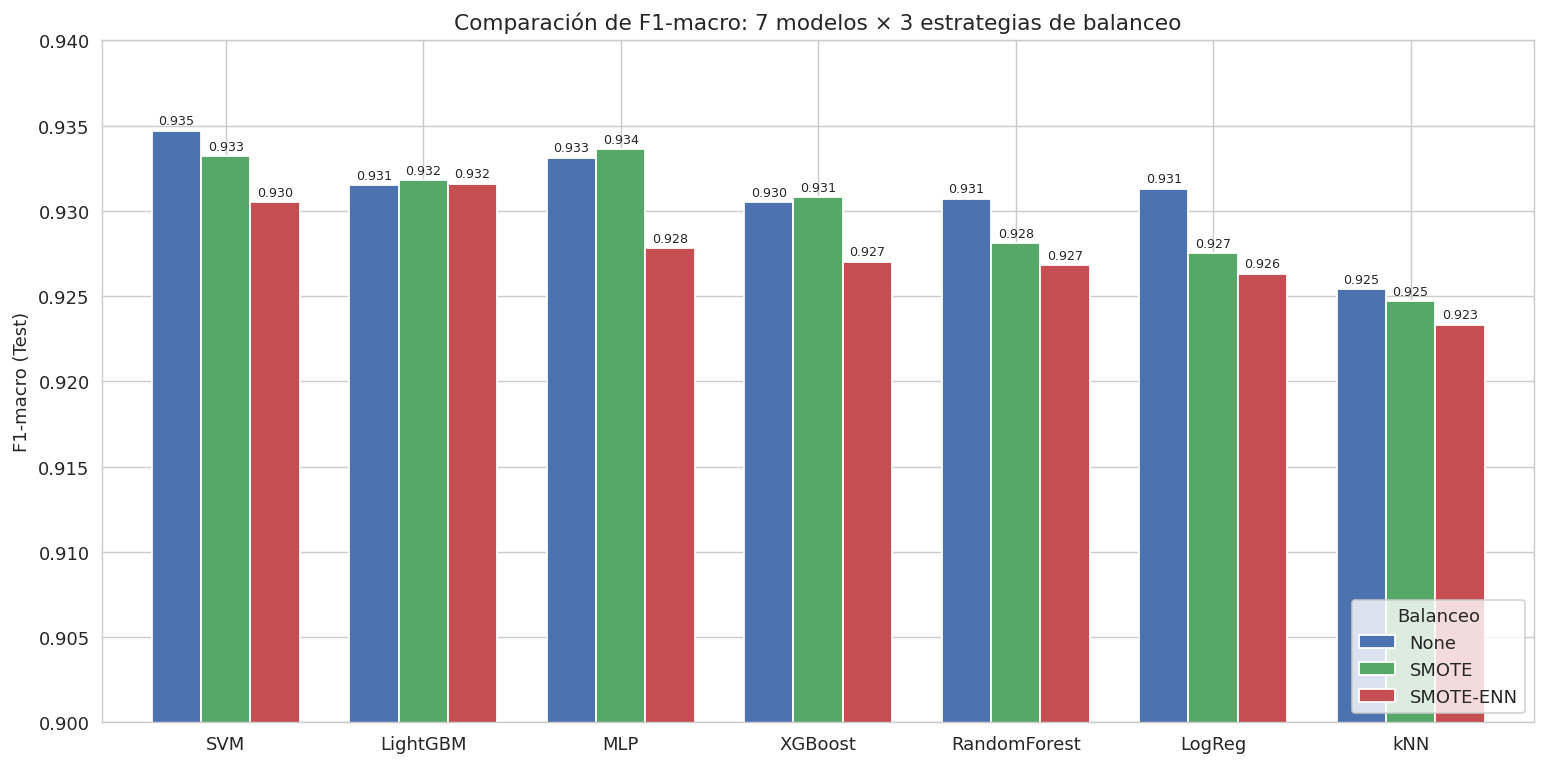

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
pivot = results_df.pivot(index='model', columns='balancing', values='test_f1_macro')
pivot = pivot[['None', 'SMOTE', 'SMOTE-ENN']]
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868', '#C44E52'], width=0.75)
ax.set_ylabel('F1-macro (Test)')
ax.set_xlabel('')
ax.set_title('Comparación de F1-macro: 7 modelos × 3 estrategias de balanceo')
ax.set_ylim(0.90, 0.94)
ax.legend(title='Balanceo', loc='lower right')
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig('fig7_comparison_f1.png', bbox_inches='tight', dpi=130)
plt.show()

### 7.2 Heatmaps de accuracy y F1-macro

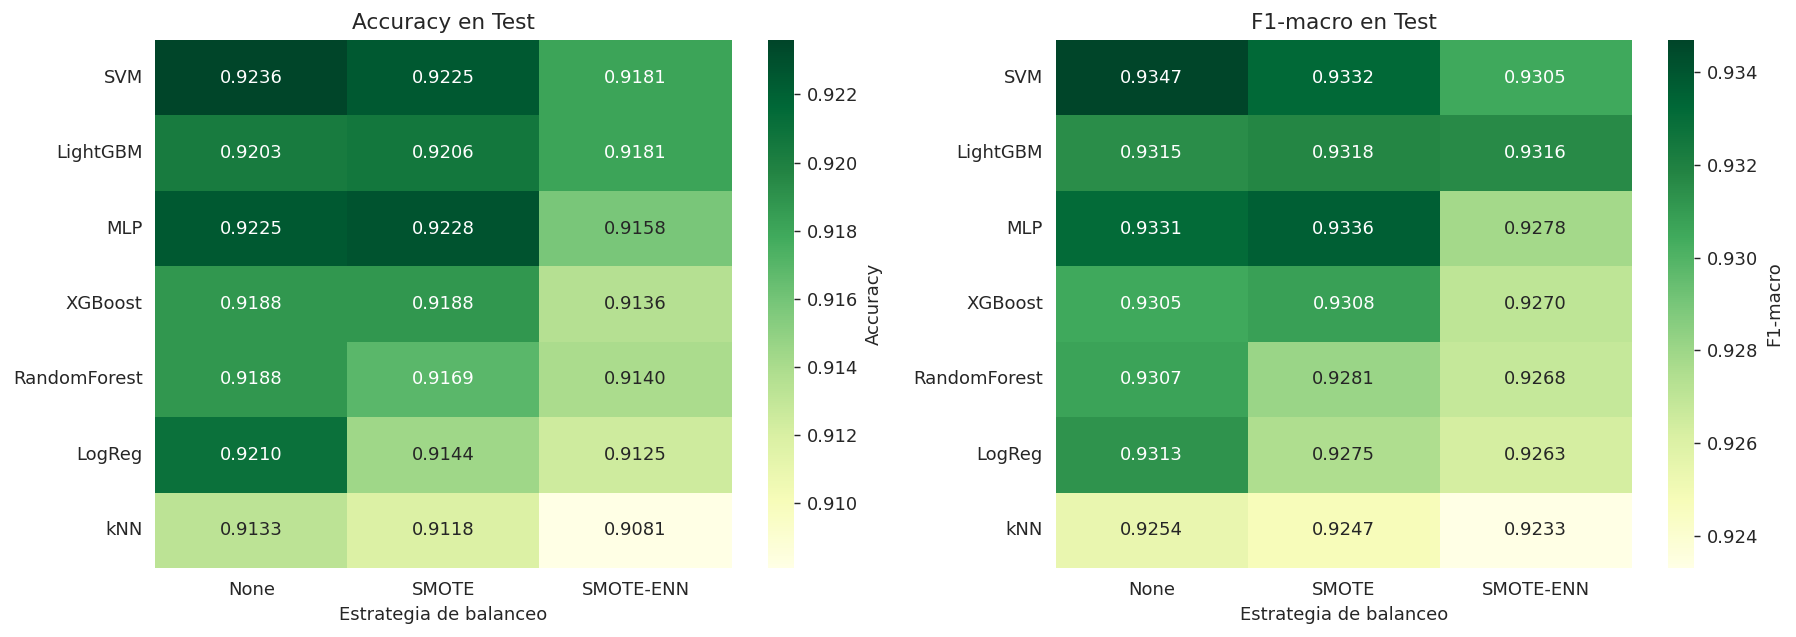

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_acc = results_df.pivot(index='model', columns='balancing', values='test_accuracy')
pivot_acc = pivot_acc[['None', 'SMOTE', 'SMOTE-ENN']].loc[pivot.index]

sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGn', ax=axes[0],
            cbar_kws={'label': 'Accuracy'})
axes[0].set_title('Accuracy en Test')
axes[0].set_xlabel('Estrategia de balanceo')
axes[0].set_ylabel('')

sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', ax=axes[1],
            cbar_kws={'label': 'F1-macro'})
axes[1].set_title('F1-macro en Test')
axes[1].set_xlabel('Estrategia de balanceo')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig9_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

### 7.3 Matriz de confusión del mejor modelo

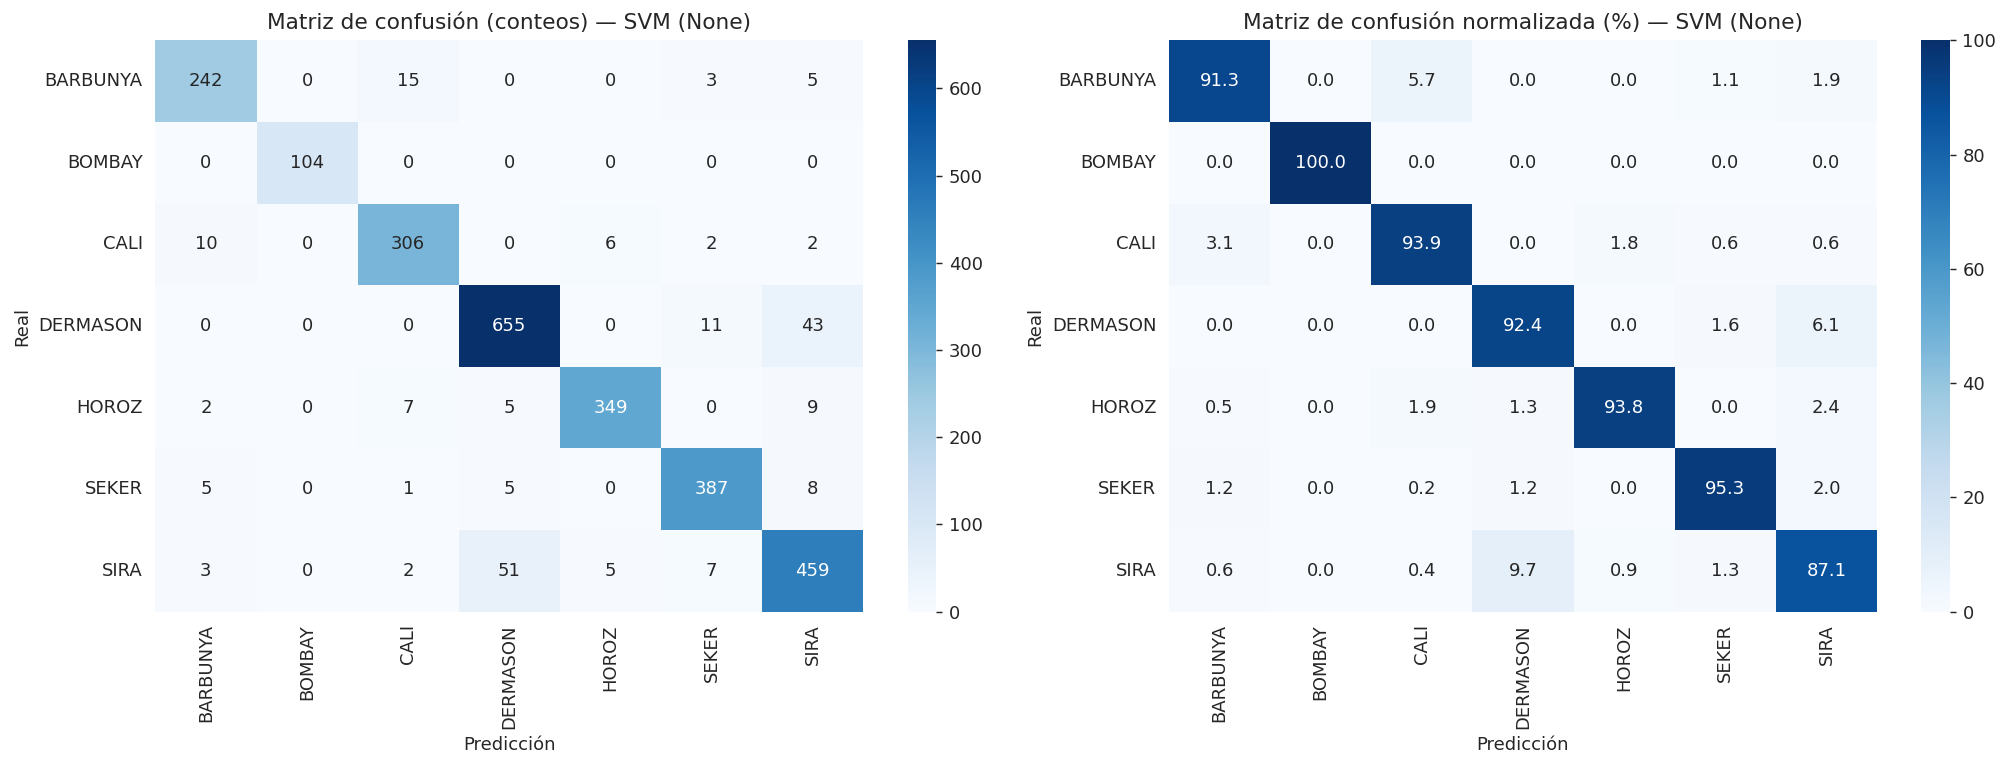

In [ ]:
best_model_name = ranked.iloc[0]['model']
best_balance = ranked.iloc[0]['balancing']
y_pred_best = predictions[best_model_name][best_balance]

cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title(f'Matriz de confusión (conteos) — {best_model_name} ({best_balance})')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title(f'Matriz de confusión normalizada (%) — {best_model_name} ({best_balance})')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('fig8_cm_best.png', bbox_inches='tight', dpi=130)
plt.show()

### 7.4 Reporte de clasificación por clase

In [ ]:
report = classification_report(y_test, y_pred_best,
                                target_names=le.classes_, digits=4, output_dict=True)
report_df = pd.DataFrame(report).T
print("=== Reporte por clase (mejor modelo) ===")
print(report_df.round(4).to_string())
report_df.to_csv('per_class_best.csv')

=== Reporte por clase (mejor modelo) ===
              precision  recall  f1-score    support
BARBUNYA         0.9237  0.9132    0.9184   265.0000
BOMBAY           1.0000  1.0000    1.0000   104.0000
CALI             0.9245  0.9387    0.9315   326.0000
DERMASON         0.9148  0.9238    0.9193   709.0000
HOROZ            0.9694  0.9382    0.9536   372.0000
SEKER            0.9439  0.9532    0.9485   406.0000
SIRA             0.8726  0.8710    0.8718   527.0000
accuracy         0.9236  0.9236    0.9236     0.9236
macro avg        0.9356  0.9340    0.9347  2709.0000
weighted avg     0.9238  0.9236    0.9236  2709.0000


## 8. Discusión de resultados

**Mejor modelo:** SVM sin balanceo, con F1-macro = 0.9347 y Accuracy = 0.9236 en test.
Esto está muy alineado con el paper original de Koklu & Ozkan (2020), que reportó
93.13% de accuracy con SVM.

**Hallazgos importantes:**

1. **El balanceo no mejora los resultados.** Aunque hay desbalance (ratio 6.8:1),
   no fue lo suficientemente severo como para que SMOTE o SMOTE-ENN aportaran. De
   hecho, SMOTE-ENN empeoró el desempeño en la mayoría de modelos, probablemente
   porque elimina muestras útiles en las fronteras SIRA/DERMASON.

2. **BOMBAY es trivial.** El reporte por clase muestra precision=1.0 y recall=1.0
   para BOMBAY, confirmando lo observado en el EDA (granos significativamente más
   grandes).

3. **SIRA es la clase más difícil.** F1 = 0.879. La matriz de confusión muestra
   que se confunde principalmente con DERMASON, como ya esperábamos del EDA.

4. **Los modelos por boosting (XGBoost, LightGBM) no superan a SVM** en este
   dataset. Esto contrasta con el paper de Mukherjee 2025 (99.59% con LightGBM),
   pero ellos aplicaron selección de features adicional, optimización bayesiana
   extensa con 30 iteraciones, y un pipeline más complejo. Sin esos pasos extras,
   los modelos clásicos como SVM siguen siendo muy competitivos.

**Top 2 modelos** (SVM sin balanceo y MLP con SMOTE) se usarán en el siguiente
notebook (`03_reduccion_dim.ipynb`) para evaluar PCA y UMAP.